# Dependencias

In [ ]:
!pip install sweetviz
!pip install seaborn
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 56.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import keras
from keras import backend as K
from tqdm import tqdm
from tqdm.keras import TqdmCallback
from tensorflow.keras.models import save_model, load_model

In [ ]:
#Conectar con Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/1. TFG/1. CODIGO/'

In [ ]:
# Lista de nombres de archivos
files = [
    'junio2023.csv', 'julio2023.csv'
]

In [ ]:
# Lista para almacenar DataFrames
dataframes = []

In [ ]:
# Cargamos cada archivo, procesamos y agregamos a la lista
for file_name in files:
    full_path = base_path + file_name
    df = pd.read_csv(full_path, sep=';')
    df = df[['description', 'name_description', 'name', 'timestamp', 'value']]
    dataframes.append(df)

In [ ]:
# Concatenamos todos los DataFrames
df_final = pd.concat(dataframes)

In [ ]:
# Tomando timestamp como columna
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'], errors='coerce')  # Convertir 'timestamp' a datetime
df_final['timestamp'] = df_final['timestamp'].dt.floor('min')  # Redondear al minuto más cercano
df_final.dropna(subset=['timestamp'], inplace=True)  # Eliminar filas donde 'timestamp' es NaT

# Configurar 'timestamp' como índice
df_final.set_index('timestamp', inplace=True)


In [ ]:
#Guardamos el dataframe unificado
#df_final.to_csv('/content/drive/MyDrive/1. TFG/1. CODIGO/datos_unificados.csv', sep=';', index=True)

# Mostramos el DataFrame resultante
#print(df_final)

In [ ]:
df_final

,description,name_description,name,value
timestamp,,,,
2023-06-01 00:06:00,Estado Bomba de Calor_1,NAE-01/N2 Trunk 1.DC_005.BOM_CALO EST_GBC1Esta...,NAE-01/N2 Trunk 1.DC_005.BOM_CALO EST_GBC1,NaN
2023-06-01 00:06:00,Estado Bomba de Calor_2,NAE-01/N2 Trunk 1.DC_005.BOM_CALO EST_GBC2Esta...,NAE-01/N2 Trunk 1.DC_005.BOM_CALO EST_GBC2,NaN
2023-06-01 00:06:00,Alarma Averia BC1,NAE-01/N2 Trunk 1.DX_001.BOM_CALO AL_AVBC1Alar...,NAE-01/N2 Trunk 1.DX_001.BOM_CALO AL_AVBC1,NaN
2023-06-01 00:06:00,Alarma Averia BC2,NAE-01/N2 Trunk 1.DX_001.BOM_CALO AL_AVBC2Alar...,NAE-01/N2 Trunk 1.DX_001.BOM_CALO AL_AVBC2,NaN
2023-06-01 00:06:00,Estado B.Calor_1_1,NAE-01/N2 Trunk 1.DX_001.BOM_CALO ES_BC1_1Esta...,NAE-01/N2 Trunk 1.DX_001.BOM_CALO ES_BC1_1,NaN
...,...,...,...,...
2023-07-31 23:50:00,Presión baja circuito 1,B'Prod1'BC'PLoPresión baja circuito 1,B'Prod1'BC'PLo,NaN
2023-07-31 23:50:00,Presión de succión C1,B'Prod1'BC'PSC1Presión de succión C1,B'Prod1'BC'PSC1,0.0
2023-07-31 23:50:00,Presión de Succión C2,B'Prod1'BC'PSC2Presión de Succión C2,B'Prod1'BC'PSC2,0.0


# Preprocesamiento de datos

Seleccionamos las columnas de interés:
1. 'Description' nos da informacion sobre el nombre de las variables de nuestra bomba
2. 'Name_description' y 'name' nos dan informacion sobre los nombres completos
3. 'Timestamp' da los valores temporales
4. 'Value' da los valores correspondientes a cada variable

Nos interesa la BC2, en este caso la filtramos de la columna 'name_description' ya que la especifica como 'BC2'

In [ ]:
df_filtered_bc = df_final[df_final['name_description'].str.contains('BC2')]


In [ ]:
print(df_filtered_bc)

                                   description  \
timestamp                                        
2023-06-01 00:06:00    Estado Bomba de Calor_2   
2023-06-01 00:06:00          Alarma Averia BC2   
2023-06-01 00:06:00           Estado flujo BC2   
2023-06-01 00:06:00        MP Bomba de Calor_2   
2023-06-01 00:06:00     Temperatura impul. BC2   
...                                        ...   
2023-07-31 23:50:00  Automático Manual Bomba 1   
2023-07-31 23:50:00  Automático Manual Bomba 2   
2023-07-31 23:50:00             Valor de mando   
2023-07-31 23:50:00                      Mando   
2023-07-31 23:50:00                      Mando   

                                                      name_description  \
timestamp                                                                
2023-06-01 00:06:00  NAE-01/N2 Trunk 1.DC_005.BOM_CALO EST_GBC2Esta...   
2023-06-01 00:06:00  NAE-01/N2 Trunk 1.DX_001.BOM_CALO AL_AVBC2Alar...   
2023-06-01 00:06:00  NAE-01/N2 Trunk 1.DX_001.BOM_CAL

Queremos asegurarnos de que 'timestamp' esta ordenado de menor a mayor
Convertimos 'timestamp' a datetime, especificando que el dia va primero si es necesario
Aqui metemos el .copy porque nos daba si no un warning el codigo referido a eso en esta linea

In [ ]:
df_filtered = df_filtered_bc.copy()

In [ ]:
print(df_final.columns)


Index(['description', 'name_description', 'name', 'value'], dtype='object')


Convertimos 'timestamp' a datetime, los valores no convertibles se marcan como NaT

In [ ]:
#df_final['timestamp'] = pd.to_datetime(df_final['timestamp'], errors='coerce')

Eliminamos las filas donde 'timestamp' es NaT

In [ ]:
#df_filtered.dropna(subset=['timestamp'], inplace=True)

Ahora, todos los valores en 'timestamp' están garantizados de ser datetime y podemos proceder

In [ ]:
#df_filtered['timestamp'] = df_filtered['timestamp'].dt.floor('min')

Una vez limpio, puedes proceder a establecer 'timestamp' como el índice del DataFrame

In [ ]:
#df_filtered.set_index('timestamp', inplace=True)

Eliminamos todos aquellos valores NaN de nuestra columna value con el comando .dropna

In [ ]:
df_filtered.dropna(subset=['value'], inplace=True)

Obtenemos las variables únicas de la columna 'description' en df_filtered con el comando .unique()

In [ ]:
# Lista de variables a omitir #CAMBIOS
variables_a_omitir = ['Consigna Temp Deposito', 'Potencia actual', 'Potencia demandada']

In [ ]:
df_variables = df_filtered['description'].unique()

Creamos un diccionario para guardar cada DataFrame por variable
Vamos a guardar cada variable en un dataframe, con su correspondiente timestamp

In [ ]:
df_per_variable = {}

Lista para almacenar cada DataFrame temporal y unificarlo

In [ ]:
df_union = []

Creamos nuestro loop para ir seleccionando cada variable unica. El loop funciona de tal forma que va buscando las variables unicas de la col description.
Luego busca su value y renombra la columna como la de la columna description.
Lo almacenamos en nuestro diccionario.
Los unimos con el comando append.

In [ ]:
for variable in df_variables: #CAMBIOS
    if variable in variables_a_omitir:
        continue  # Si la variable está en la lista de omisión, se salta el procesamiento de esta variable

    # Filtra por cada variable única que no está en la lista de omisión
    df_filtrado = df_filtered[df_filtered['description'] == variable]

    # Renombra la columna 'value' para reflejar el nombre de la variable
    df_final = df_filtrado[['value']].rename(columns={'value': variable})

    # Almacena el DataFrame en el diccionario destinado a ello
    df_per_variable[variable] = df_final

    # Añade el DataFrame a la lista de DataFrames temporales
    df_union.append(df_final)

In [ ]:
print(df_per_variable)

{'Temperatura impul. BC2':                      Temperatura impul. BC2
timestamp                                  
2023-06-01 00:06:00               13.023438
2023-06-01 00:20:00               12.921875
2023-06-01 00:35:00               12.945312
2023-06-01 00:49:00               12.937500
2023-06-01 01:03:00               12.882812
...                                     ...
2023-07-31 22:52:00               28.906250
2023-07-31 23:06:00               28.953125
2023-07-31 23:21:00               29.000000
2023-07-31 23:36:00               29.031250
2023-07-31 23:50:00               29.046875

[4082 rows x 1 columns], 'Temperatura retorno. BC2':                      Temperatura retorno. BC2
timestamp                                    
2023-06-01 00:06:00                 10.539062
2023-06-01 00:20:00                 10.812500
2023-06-01 00:35:00                 11.625000
2023-06-01 00:49:00                 11.625000
2023-06-01 01:03:00                 11.453125
...                      

Concatenamos todos nuestros dataframes utilizando el índice timestamp para unirlos de manera uniforme (axis 1 para col)

In [ ]:
for i, df in enumerate(df_union):
    # Eliminamos duplicados, manteniendo la primera aparición
    df_union[i] = df.loc[~df.index.duplicated(keep='first')]


In [ ]:
df_unificado = pd.concat(df_union, axis=1) #estamos uniendo muchos dataframe, no solo uno
print(df_unificado)

                     Temperatura impul. BC2  Temperatura retorno. BC2  \
timestamp                                                               
2023-06-01 00:06:00               13.023438                 10.539062   
2023-06-01 00:20:00               12.921875                 10.812500   
2023-06-01 00:35:00               12.945312                 11.625000   
2023-06-01 00:49:00               12.937500                 11.625000   
2023-06-01 01:03:00               12.882812                 11.453125   
...                                     ...                       ...   
2023-07-31 22:52:00               28.906250                 28.218750   
2023-07-31 23:06:00               28.953125                 28.312500   
2023-07-31 23:21:00               29.000000                 28.312500   
2023-07-31 23:36:00               29.031250                 28.312500   
2023-07-31 23:50:00               29.046875                 28.312500   

                     Temperatura de entrada  Tempe

Guardarme como un CSV las variables que me saca y revisar

In [ ]:
df_unificado.to_csv('datos_unificados.csv', sep=';', index=True)

In [ ]:
print(df_unificado.columns)

Index(['Temperatura impul. BC2', 'Temperatura retorno. BC2',
       'Temperatura de entrada', 'Temperatura de salida',
       'Temperatura Depósito Inercia', 'Caudal', 'Potencia',
       'Temperatura de impulsión', 'Temperatura de retorno',
       'Factor de potencia', 'Energía Activa', 'Enerrgía Reactiva',
       'Frecuencia', 'Corriente L1', 'Corriente L2', 'Corriente L3',
       'Máxima potencia activa en periodo actual', 'Potencia activa fase L1',
       'Potencia activa fase L2', 'Potencia activa fase L3',
       'Potencia Activa Total', 'Potencia aparente fase L1',
       'Potencia aparente fase L2', 'Potencia aparente fase L3',
       'Potencia aparente total', 'Potencia reactiva fase L1',
       'Potencia reactiva fase L2', 'Potencia reactiva fase L3',
       'Potencia Reactiva Total', 'Tensión línea L1-L2', 'Tensión línea L2-L3',
       'Tensión línea L3-L1', 'Temperatura entrada Evaporador',
       'Temperatura de salida evaporador'],
      dtype='object')


Nos interesa correlacionar respecto a nuestra temperatura de salida ya que sera nuestra variable de salida
Nos aseguramos de que la temperatura de salida este en nuestros datos

In [ ]:
if 'Temperatura de salida' in df_unificado.columns:
    # Calcula la matriz de correlación
    correlacion = df_unificado.corr()

    # Imprimimos nuestra matriz de correlacion respecto a la temperatura de salida
    print(correlacion['Temperatura de salida'])
else:
    print("La columna 'Temperatura de salida' no se encuentra en el DataFrame unificado.")


Temperatura impul. BC2                      0.657392
Temperatura retorno. BC2                    0.636917
Temperatura de entrada                      0.972180
Temperatura de salida                       1.000000
Temperatura Depósito Inercia                0.463418
Caudal                                     -0.691374
Potencia                                   -0.605667
Temperatura de impulsión                    0.964506
Temperatura de retorno                      0.960125
Factor de potencia                          0.579871
Energía Activa                              0.052995
Enerrgía Reactiva                           0.052728
Frecuencia                                 -0.036940
Corriente L1                               -0.609382
Corriente L2                               -0.606801
Corriente L3                               -0.609622
Máxima potencia activa en periodo actual   -0.650648
Potencia activa fase L1                    -0.601726
Potencia activa fase L2                    -0.

### Gráficas de correlaciones

Sweetviz

In [ ]:
# Asegurándonos de que estamos usando el DataFrame correcto
# y ajustando las etiquetas y nombres de las columnas correctamente

# Plotting
#plt.figure(figsize=(14, 7))

# Graficar Temperaturas BC2
#plt.subplot(2, 1, 1)  # Dos filas, una columna, primer subplot
#plt.plot(df_unificado.index, df_unificado['Temperatura impul. BC2'], label='Temperatura Impulsión BC2', color='blue')
#plt.plot(df_unificado.index, df_unificado['Temperatura retorno. BC2'], label='Temperatura Retorno BC2', color='green')
#plt.title('Temperaturas de Impulsión y Retorno BC2')
#plt.xlabel('Timestamp')
#plt.ylabel('Temperatura (°C)')
#plt.legend()

# Graficar Temperaturas Normales
#plt.subplot(2, 1, 2)  # Dos filas, una columna, segundo subplot
#plt.plot(df_unificado.index, df_unificado['Temperatura de impulsión'], label='Temperatura de Impulsión', color='red')
#plt.plot(df_unificado.index, df_unificado['Temperatura de retorno'], label='Temperatura de Retorno', color='purple')
#plt.title('Temperaturas Normales de Impulsión y Retorno')
#plt.xlabel('Timestamp')
#plt.ylabel('Temperatura (°C)')
#plt.legend()

#plt.tight_layout()
#plt.show()

In [ ]:
# Analizamos el DataFrame
#reporte = sv.analyze(df_unificado)

# Creamos el reporte en HTML
#reporte.show_html('Reporte_Sweetviz.html')

In [ ]:
#from IPython.display import HTML
#HTML(filename='Reporte_Sweetviz.html')


Mapa de calor

<ipython-input-35-f464db5fa051>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette=palette, edgecolor='w', alpha=0.8)  # Ajusta alpha a 0.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

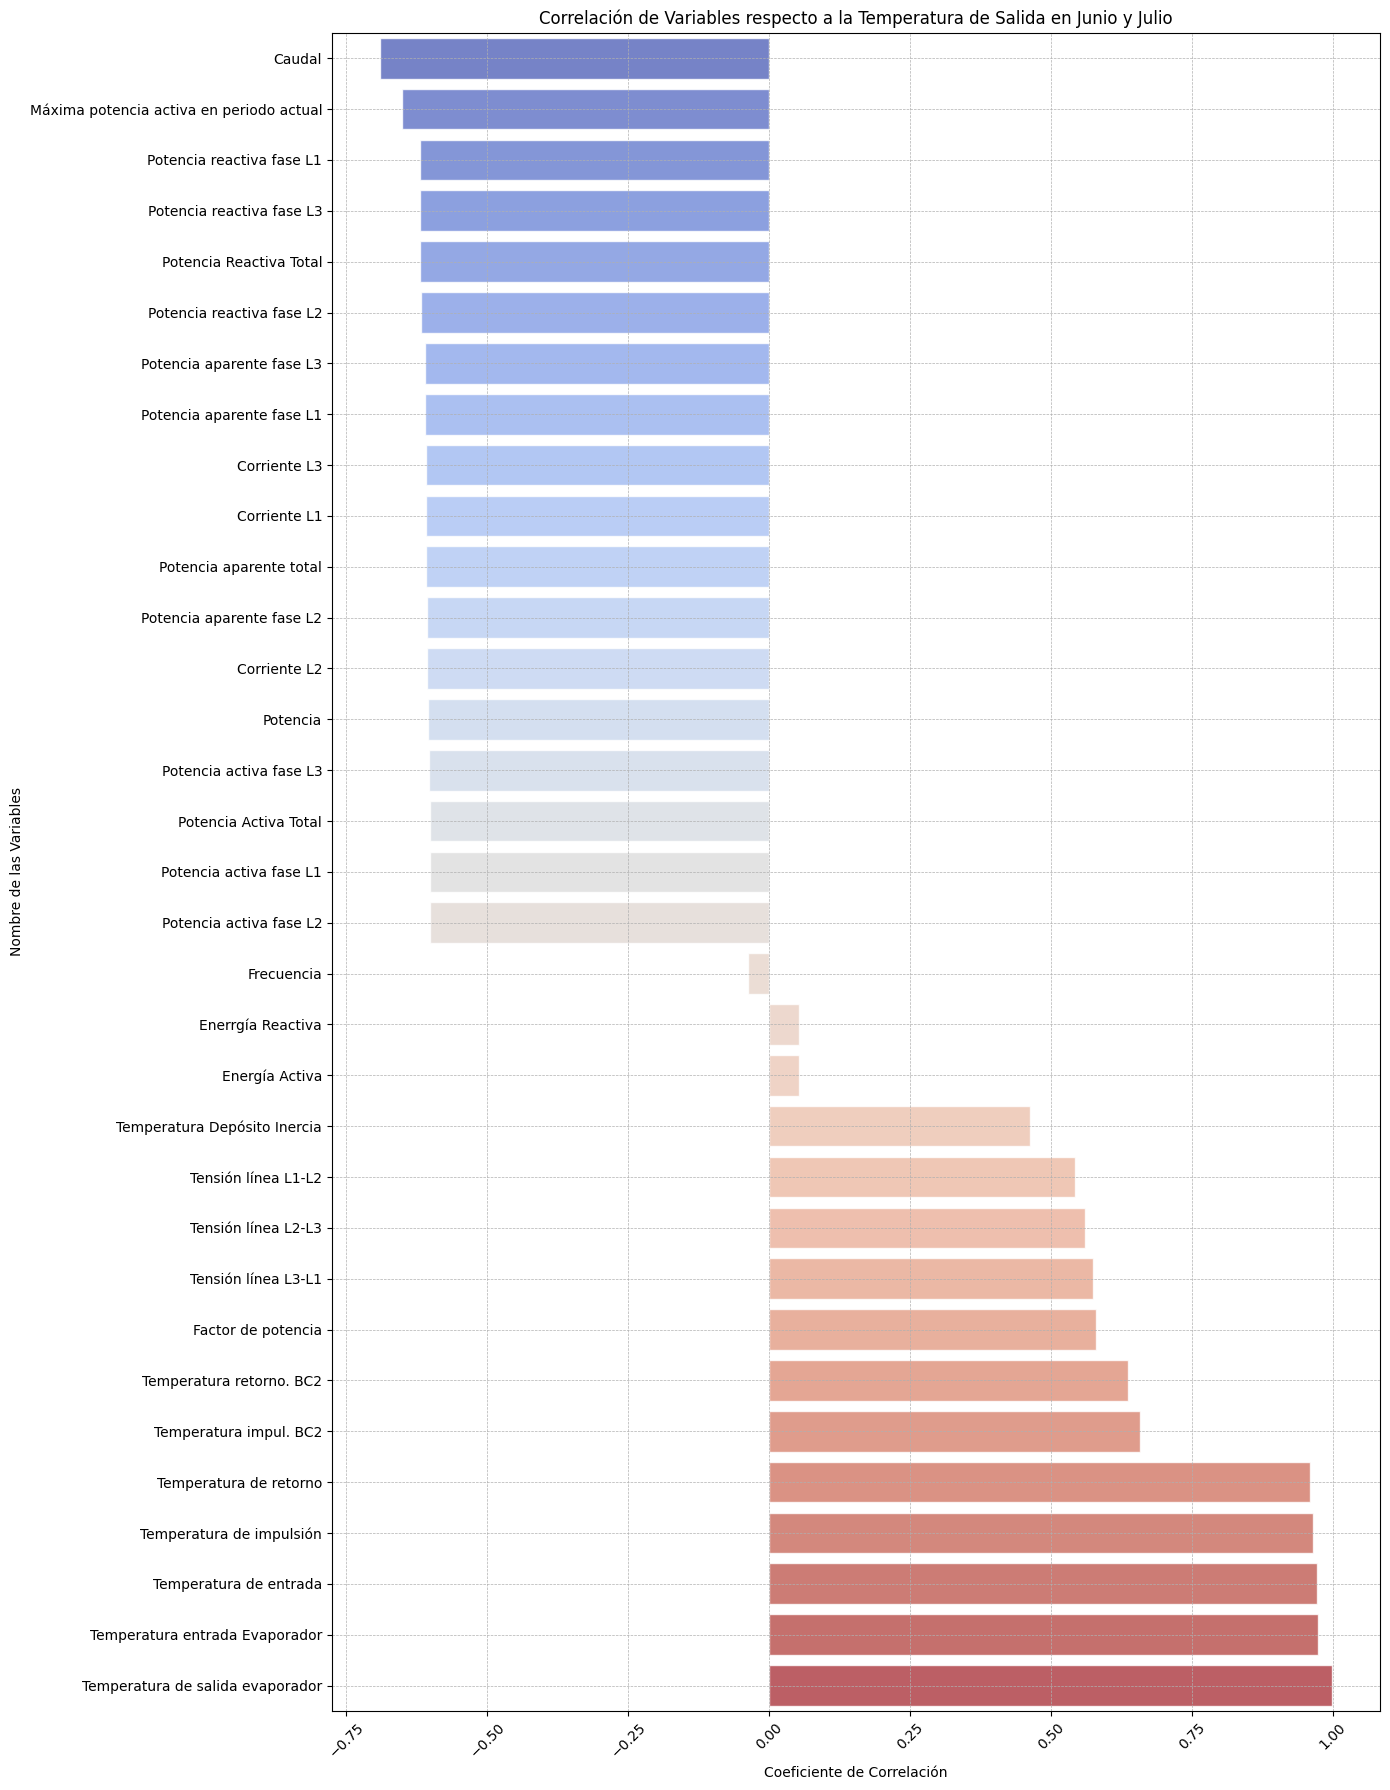

In [ ]:
from google.colab import files
# Aísla la correlación con respecto a 'Temperatura de salida'
correlaciones = correlacion['Temperatura de salida'].drop('Temperatura de salida')  # Elimina la correlación de ella misma

# Asumiendo que 'correlations' es tu Serie de correlaciones ya calculada
correlaciones = correlaciones.sort_values()  # Ordena las correlaciones

# Configura el tamaño de la figura
plt.figure(figsize=(14, 18))

# Crea un gráfico de barras horizontal con una paleta de colores divergente
# Crea un gráfico de barras horizontal con una paleta de colores personalizada y opacidad ajustada
palette = sns.color_palette("coolwarm", len(correlaciones))  # Genera una paleta
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette=palette, edgecolor='w', alpha=0.8)  # Ajusta alpha a 0.8

# Mejora la legibilidad
plt.xticks(rotation=45)  # Rota las etiquetas del eje X para mejor visibilidad
plt.yticks(fontsize=10)  # Ajusta el tamaño de la fuente de las etiquetas del eje Y

# Añade líneas de cuadrícula para mejorar la claridad
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Añade título y etiquetas
plt.title('Correlación de Variables respecto a la Temperatura de Salida en Junio y Julio')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Nombre de las Variables')

# Optimiza la disposición de los elementos dentro de la figura para que todo quepa correctamente
plt.tight_layout()

# Guardar el gráfico como un archivo JPG
plt.savefig('grafico_correlacionCalor.jpg', format='jpg', dpi=300)

# Descargar el archivo a tu computadora local
files.download('grafico_correlacionCalor.jpg')
# Muestra el gráfico
plt.show()


Generalidades 1: Creamos nuestra columna adicional con la temperatura desfasada +28 min. Desplazando la columna de 'Temperatura de salida' basado en tiempo (28 minutos). Creando una nueva columna 'Tsalida_28' que tendrá los valores desplazados

### Generacion de la columna Output

In [ ]:
# Función para encontrar el valor más cercano a 28 minutos después
def find_future_temp_28min(row_timestamp, df):
    # Calculamos el límite de tiempo 28 minutos en el futuro
    time_limit = row_timestamp + pd.Timedelta(minutes=28)
    # Filtramos el DataFrame para los registros después del límite de tiempo
    future_df = df.loc[time_limit:]
    if not future_df.empty:
        # Retornamos el primer valor de 'Temperatura de salida' después del límite de tiempo
        return future_df.iloc[0]['Temperatura de salida']
    else:
        # Si no hay registros suficientemente futuros, retornamos NaN
        return pd.NA

In [ ]:
# Aseguramos que el índice esté en formato datetime si aún no lo está
df_unificado.index = pd.to_datetime(df_unificado.index)

In [ ]:
# Aplicamos la función ajustada
df_unificado['Tsalida_28_ajustado_retroceso'] = df_unificado.index.to_series().apply(lambda x: find_future_temp_28min(x, df_unificado))

df_unificado['Tsalida_28_ajustado_retroceso'] = pd.to_numeric(df_unificado['Tsalida_28_ajustado_retroceso'], errors='coerce')

# Eliminamos las filas donde 'Tsalida_28_ajustado_retroceso' es NaN
df_unificado.dropna(subset=['Tsalida_28_ajustado_retroceso'], inplace=True)

In [ ]:
# Guardamos el DataFrame en un CSV llamado 'Previo_normalización.csv' antes de la normalización
csv_file_path_previo_normalizacion = 'Previo_normalización.csv'
df_unificado.to_csv(csv_file_path_previo_normalizacion, sep=';', index=True)

### Normalizado

In [ ]:
minimos = df_unificado.min(numeric_only=True)
maximos = df_unificado.max(numeric_only=True)
rangos = maximos - minimos
porcentaje_margen = 0.10  # Margen del 10%
#aquí tengo que imprimir cuál es el max y min porque necesitamos saber los valores

rangos_ajustados_porcentaje = pd.DataFrame({'Minimo Actual': minimos, 'Maximo Actual': maximos})
rangos_ajustados_porcentaje['Minimo Ajustado'] = rangos_ajustados_porcentaje['Minimo Actual'] - (rangos * porcentaje_margen)
rangos_ajustados_porcentaje['Maximo Ajustado'] = rangos_ajustados_porcentaje['Maximo Actual'] + (rangos * porcentaje_margen)

for columna in rangos_ajustados_porcentaje.index:
    min_ajustado = rangos_ajustados_porcentaje.loc[columna, 'Minimo Ajustado']
    max_ajustado = rangos_ajustados_porcentaje.loc[columna, 'Maximo Ajustado']
    df_unificado[columna] = (df_unificado[columna] - min_ajustado) / (max_ajustado - min_ajustado)

# Guardamos el DataFrame normalizado
csv_file_path_normalizado = 'df_unificado_ajustado_normalizado.csv'
df_unificado.to_csv(csv_file_path_normalizado, sep=';', index=True)

# Verificación final
print(df_unificado.head())

                     Temperatura impul. BC2  Temperatura retorno. BC2  \
timestamp                                                               
2023-06-01 00:06:00                0.232444                  0.100083   
2023-06-01 00:20:00                0.229980                  0.106670   
2023-06-01 00:35:00                0.230548                  0.126242   
2023-06-01 00:49:00                0.230359                  0.126242   
2023-06-01 01:03:00                0.229032                  0.122102   

                     Temperatura de entrada  Temperatura de salida  \
timestamp                                                            
2023-06-01 00:06:00                0.274423               0.275910   
2023-06-01 00:20:00                0.274423               0.276961   
2023-06-01 00:35:00                0.274423               0.278711   
2023-06-01 00:49:00                0.274423               0.280462   
2023-06-01 01:03:00                0.274423               0.282213  

### Correlaciones respecto a futuro

In [ ]:
# Cálculo de correlaciones en el DataFrame
correlaciones = df_unificado.corr()

# Imprimimos la correlación de 'Tsalida_28_ajustado_retroceso' con otras variables
print(correlaciones['Tsalida_28_ajustado_retroceso'])

Temperatura impul. BC2                      0.674086
Temperatura retorno. BC2                    0.652603
Temperatura de entrada                      0.958615
Temperatura de salida                       0.987356
Temperatura Depósito Inercia                0.466216
Caudal                                     -0.691656
Potencia                                   -0.608523
Temperatura de impulsión                    0.947512
Temperatura de retorno                      0.944856
Factor de potencia                          0.582388
Energía Activa                              0.052631
Enerrgía Reactiva                           0.052391
Frecuencia                                 -0.033226
Corriente L1                               -0.611156
Corriente L2                               -0.608476
Corriente L3                               -0.611356
Máxima potencia activa en periodo actual   -0.645462
Potencia activa fase L1                    -0.603354
Potencia activa fase L2                    -0.

### Dataset Completo

In [ ]:
#me monto un df y lo llamo dataset quitando las columnas que no nos interesen
# Lista de las columnas que nos interesan
columnas_interes = [
    'Temperatura de entrada', 'Temperatura de salida', 'Temperatura impul. BC2',
    'Temperatura retorno. BC2', 'Potencia Activa Total', 'Caudal',
    'Temperatura entrada Evaporador', 'Temperatura de salida evaporador',
    'Tsalida_28_ajustado_retroceso'
]

# Creación del nuevo DataFrame 'dataset' con las columnas de interés
DataSet = df_unificado[columnas_interes].copy()

# Eliminar las filas donde hay NaN en cualquiera de las columnas seleccionadas
DataSet.dropna(inplace=True)

# Muestra las primeras filas del nuevo DataFrame para verificar
print(DataSet.head())


                     Temperatura de entrada  Temperatura de salida  \
timestamp                                                            
2023-06-01 00:06:00                0.274423               0.275910   
2023-06-01 00:20:00                0.274423               0.276961   
2023-06-01 00:35:00                0.274423               0.278711   
2023-06-01 00:49:00                0.274423               0.280462   
2023-06-01 01:03:00                0.274423               0.282213   

                     Temperatura impul. BC2  Temperatura retorno. BC2  \
timestamp                                                               
2023-06-01 00:06:00                0.232444                  0.100083   
2023-06-01 00:20:00                0.229980                  0.106670   
2023-06-01 00:35:00                0.230548                  0.126242   
2023-06-01 00:49:00                0.230359                  0.126242   
2023-06-01 01:03:00                0.229032                  0.122102  

In [ ]:
DataSet

,Temperatura de entrada,Temperatura de salida,Temperatura impul. BC2,Temperatura retorno. BC2,Potencia Activa Total,Caudal,Temperatura entrada Evaporador,Temperatura de salida evaporador,Tsalida_28_ajustado_retroceso
timestamp,,,,,,,,,
2023-06-01 00:06:00,0.274423,0.275910,0.232444,0.100083,0.083944,0.083952,0.270750,0.248594,0.278711
2023-06-01 00:20:00,0.274423,0.276961,0.229980,0.106670,0.083987,0.084262,0.280790,0.252110,0.280462
2023-06-01 00:35:00,0.274423,0.278711,0.230548,0.126242,0.083944,0.083798,0.280790,0.255626,0.282213
2023-06-01 00:49:00,0.274423,0.280462,0.230359,0.126242,0.083949,0.083798,0.280790,0.259142,0.284664
2023-06-01 01:03:00,0.274423,0.282213,0.229032,0.122102,0.083996,0.083488,0.280790,0.262658,0.286415
...,...,...,...,...,...,...,...,...,...
2023-07-31 22:23:00,0.351844,0.314426,0.614464,0.523336,0.083705,0.083798,0.277443,0.280239,0.328431
2023-07-31 22:37:00,0.356067,0.321429,0.616360,0.523336,0.083719,0.083952,0.284137,0.287271,0.335434
2023-07-31 22:52:00,0.359586,0.328431,0.617876,0.525971,0.083759,0.083643,0.290830,0.294304,0.343487


In [ ]:
#DataSet=DataSet.sample(frac=1)

### Division de los datos en datos de entrenamiento, validacion y test. Y creaxion de 2 vectores de entrada por dato uno con las n variables en el tiempo actual y otro con n variables hace 14 minutos / entrenamiento

In [ ]:
#Calculamos el numero de muestras para los conjuntos de entrenamiento, validacion y pruebas
samples_entrenamiento=int(0.8*len(DataSet))
samples_validacion=int(0.1*len(DataSet))
samples_test=len(DataSet)-samples_entrenamiento-samples_validacion

#definimos la longitud de la secuencia para la entrada de mi lstm
sequence_length=2 # define el numero de vectores temporañes de n variables de la secuencia que se pasa como input al modelo

#calculamos el n de variables de entrada reduciendo a 2 el total de columnas del DataSet
n_variables=len(DataSet.columns)-2

#Tiempo de secuencia
tiempo_secuencia=1 # 14 min

#Longitudes para los conjuntos de entrenamiento, validacion y pruebas
len_DataSetEntrenamiento = samples_entrenamiento
len_DataSetValidacion = samples_validacion
len_DataSetTest = samples_test

#Inicializamos los tensores de entrada para los 3 conjuntos
DataSetEntrenamiento_entradas= np.zeros((len_DataSetEntrenamiento,sequence_length,n_variables),dtype=np.float64)
DataSetValidacion_entradas= np.zeros((len_DataSetValidacion,sequence_length,n_variables),dtype=np.float64)
DataSetTest_entradas= np.zeros((len_DataSetTest,sequence_length,n_variables),dtype=np.float64)

#Inicializamos los tensores de salida para los 3 conjuntos
DataSetEntrenamiento_salida = np.zeros((len_DataSetEntrenamiento,1),dtype=np.float64)
DataSetValidacion_salida= np.zeros((len_DataSetValidacion,1),dtype=np.float64)
DataSetTest_salida= np.zeros((len_DataSetTest,1),dtype=np.float64)

#Bucle donde preparamos los datos de entrenamiento
j=0
for i in tqdm(range(samples_entrenamiento-1)):
    DataSetEntrenamiento_entradas[j][0]=np.array(DataSet.iloc [i,1:len(DataSet.columns)-1],dtype=np.float64)
    DataSetEntrenamiento_entradas[j][1]=np.array(DataSet.iloc [i+1,1:len(DataSet.columns)-1],dtype=np.float64)
    DataSetEntrenamiento_salida[j][0]= np.array(DataSet.iloc [i+1,len(DataSet.columns)-1],dtype=np.float64)
    j=j+1

#Bucle donde preparamos los datos de validacion
j=0
for i in tqdm(range(samples_validacion-1)):
    DataSetValidacion_entradas[j][0]=np.array(DataSet.iloc [i+samples_entrenamiento,1:len(DataSet.columns)-1],dtype=np.float64)
    DataSetValidacion_entradas[j][1]=np.array(DataSet.iloc [i+samples_entrenamiento+1,1:len(DataSet.columns)-1],dtype=np.float64)
    DataSetValidacion_salida[j][0]= np.array(DataSet.iloc [i+samples_entrenamiento+1,len(DataSet.columns)-1],dtype=np.float64)
    j=j+1

#Bucle donde preparamos los datos de test
j=0
for i in tqdm(range(samples_test-1)):
    DataSetTest_entradas[j][0]=np.array(DataSet.iloc [i+samples_entrenamiento+samples_validacion,1:len(DataSet.columns)-1],dtype=np.float64)
    DataSetTest_entradas[j][1]=np.array(DataSet.iloc [i+samples_entrenamiento+samples_validacion+1,1:len(DataSet.columns)-1],dtype=np.float64)
    DataSetTest_salida[j][0]= np.array(DataSet.iloc [i+samples_entrenamiento+samples_validacion+1,len(DataSet.columns)-1],dtype=np.float64)
    j=j+1

DataSetTest_tiempo = np.array(DataSet.iloc [samples_entrenamiento+samples_validacion:samples_entrenamiento+samples_validacion+samples_test,0],dtype=np.float64)

100%|██████████| 400/400 [00:00<00:00, 3879.08it/s]


In [ ]:
DataSetEntrenamiento_entradas[0]

array([[0.27591037, 0.23244417, 0.10008281, 0.08394388, 0.08395234,
        0.27074967, 0.24859352],
       [0.27696078, 0.22997952, 0.10666968, 0.08398714, 0.08426184,
        0.28078984, 0.25210971]])

# Diseño de la arquitectura del modelo

In [ ]:
# DISEÑO DE LA ARQUITECTURA DEL MODELO LSTM, CAPAS Y NEURONAS EN CADA CAPA

#Tenemos que limpiar la sesion de Keras
K.clear_session()

#Inicializamos el modelo (usamos API Sequential de Keras porque nos permite crearlo capa a capa)
model = keras.Sequential()

#Añadimos una capa LSTM con 512 unidades
#Return_sequences=True` indica que las salidas de todas las células LSTM se devuelven para ser utilizadas por la siguiente capa LSTM
model.add(keras.layers.Bidirectional(keras.layers.LSTM(512, return_sequences=True,input_shape=(sequence_length,n_variables))))

#model.add(keras.layers.Bidirectional(keras.layers.LSTM(256,return_sequences=True)))

#Añadimos otra capa LSTM con 512 unidades. No especifica el return sequences así que solo devuelve la ultima capa
model.add(keras.layers.Bidirectional(keras.layers.LSTM(512)))

#Capa dropout para reducir OVERFITTING en el entrenamiento
model.add(keras.layers.Dropout(0.1))

#Añadimos capas densas
model.add(keras.layers.Dense(256,activation='relu')) #Dense  0 neurona tipo perceptron
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dense(1))

#Compilamos el modelo con optimizador 'adam' ...
model.compile(optimizer="adam", loss="mse", metrics=["mean_absolute_error"])

# Entrenamiento del Modelo

In [ ]:
history_1 = model.fit(DataSetEntrenamiento_entradas, DataSetEntrenamiento_salida, epochs=100, batch_size=64,
                    validation_data=(DataSetValidacion_entradas, DataSetValidacion_salida),verbose=0, callbacks=[TqdmCallback(verbose=0)])

0epoch [00:00, ?epoch/s]

In [ ]:
#Dataset con datos que no se han utilizado en el entrenamiento
DataSetTest_entradas

array([[[0.19712886, 0.51019035, 0.43262572, ..., 0.08348808,
         0.19712183, 0.17123769],
        [0.20763303, 0.51474045, 0.43526046, ..., 0.08379759,
         0.19712183, 0.17827003]],

       [[0.20763303, 0.51474045, 0.43526046, ..., 0.08379759,
         0.19712183, 0.17827003],
        [0.21638653, 0.51853221, 0.43526046, ..., 0.08348808,
         0.19712183, 0.18881856]],

       [[0.21638653, 0.51853221, 0.43526046, ..., 0.08348808,
         0.19712183, 0.18881856],
        [0.22514003, 0.52308232, 0.43526046, ..., 0.08410709,
         0.20046856, 0.1958509 ]],

       ...,

       [[0.32843138, 0.61787624, 0.52597109, ..., 0.08364284,
         0.29083   , 0.29430379],
        [0.33543418, 0.61901376, 0.52822945, ..., 0.08379759,
         0.2941767 , 0.30485232]],

       [[0.33543418, 0.61901376, 0.52822945, ..., 0.08379759,
         0.2941767 , 0.30485232],
        [0.34348738, 0.62015129, 0.52822945, ..., 0.08395234,
         0.30087017, 0.31188466]],

       [[0.      

# Test de la prediccion del Moelo

In [ ]:
prediction = model.predict(DataSetTest_entradas)

13/13 [==============================] - 1s 4ms/step


In [ ]:
prediction

array([[0.217024  ],
       [0.22487588],
       [0.23083712],
       [0.23893589],
       [0.24737917],
       [0.25557476],
       [0.26541257],
       [0.27006176],
       [0.27490792],
       [0.279858  ],
       [0.2856134 ],
       [0.2917593 ],
       [0.29820868],
       [0.30398315],
       [0.3100895 ],
       [0.31507748],
       [0.32060012],
       [0.3276851 ],
       [0.33642146],
       [0.3422013 ],
       [0.34835485],
       [0.3538109 ],
       [0.35775164],
       [0.36241543],
       [0.36649844],
       [0.2511048 ],
       [0.3054522 ],
       [0.16092491],
       [0.12543124],
       [0.12414449],
       [0.13120367],
       [0.12566173],
       [0.12694138],
       [0.12679416],
       [0.12371226],
       [0.12411448],
       [0.1353117 ],
       [0.13302268],
       [0.13123566],
       [0.1312277 ],
       [0.12299904],
       [0.11818945],
       [0.11921002],
       [0.12222844],
       [0.12560812],
       [0.12869884],
       [0.13321596],
       [0.135

In [ ]:
#Des-normalizar
rangos_ajustados_porcentaje

,Minimo Actual,Maximo Actual,Minimo Ajustado,Maximo Ajustado
Temperatura impul. BC2,6.878906,41.218750,3.444922,44.652734
Temperatura retorno. BC2,9.843750,44.437500,6.384375,47.896875
Temperatura de entrada,8.320000,32.000000,5.952000,34.368000
Temperatura de salida,6.920000,30.719999,4.540000,33.099999
Temperatura Depósito Inercia,10.320000,27.369999,8.615000,29.074999
Caudal,0.000000,53.849998,-5.385000,59.234998
Potencia,0.000000,545000.000000,-54500.000000,599500.000000
Temperatura de impulsión,7.000000,28.000000,4.900000,30.100000
Temperatura de retorno,7.000000,29.000000,4.800000,31.200000
Factor de potencia,0.683389,0.848358,0.666892,0.864855


In [ ]:
DataSetTest = DataSet

In [ ]:
#Definimos rangos minimo y maximo del rango de salida de las temperaturas para desnormalizar la prediccion y pasarla a ºC
rango_temp_sal_min = 4.540000
rango_temp_sal_max = 33.099999

#Usamos el modelo para hacer las predicciones (usamos las entradas de nuestro conjunto de test)
prediction = model.predict(DataSetTest_entradas)

#Inicializamos matriz para meter tiempos, temperaturas reales y predichas y el error
datos_salida= np.zeros((len(DataSetTest_salida),4))

#Desnormalizamos
datos_salida[:,0]=DataSetTest_tiempo
datos_salida[:,1]=(rango_temp_sal_max-rango_temp_sal_min)*np.transpose(DataSetTest_salida)+rango_temp_sal_min
datos_salida[:,2]=(rango_temp_sal_max-rango_temp_sal_min)*np.transpose(prediction)+rango_temp_sal_min
datos_salida[:,3]=(rango_temp_sal_max-rango_temp_sal_min)*np.transpose(DataSetTest_salida)+-(rango_temp_sal_max-rango_temp_sal_min)*np.transpose(prediction)

13/13 [==============================] - 0s 4ms/step


In [ ]:
datos_salida #FALTA POR PONER EL TIMESTAMP COMO PRIMERA COLUMNA sería bueno calcular el error relativo (dividir este error por el valor real)

array([[ 0.26105012, 10.96999914, 10.73820496,  0.23179367],
       [ 0.2680884 , 11.21999914, 10.96245575,  0.25754383],
       [ 0.27442287, 11.44999964, 11.1327076 ,  0.31729153],
       ...,
       [ 0.35958616, 14.56999951, 14.0438633 ,  0.52613618],
       [ 0.36310532, 14.74999982, 14.23457718,  0.5154226 ],
       [ 0.36662441,  4.54      ,  4.65537071, -0.11537067]])

Root Mean Square Error (RMSE): 0.9831841828261603
Desviación Estándar de los Errores (Sigma): 0.9830894751046424
Percentil 95 de los Errores: 0.5154226000926414


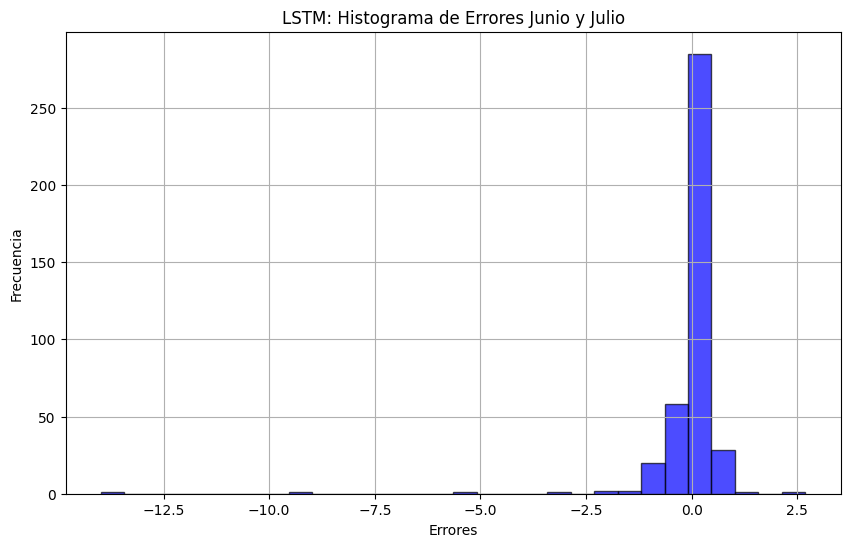

In [ ]:
errors = datos_salida[:, 3]

#RMSE
rmse = np.sqrt(np.mean(errors**2))
print("Root Mean Square Error (RMSE):", rmse)

#desviación estándar
sigma = np.std(errors)
print("Desviación Estándar de los Errores (Sigma):", sigma)

#Calcular el Percentil 95
percentil_95 = np.percentile(errors, 95)
print("Percentil 95 de los Errores:", percentil_95)

#Histograma
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('LSTM: Histograma de Errores Junio y Julio')
plt.xlabel('Errores')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

JUNIO JULIO